# 🎙️ Module 4 — Audio Data Preprocessing

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS  
**Goal:** Load, inspect, clean, and standardise all audio files so they are  
ready for feature extraction in Module 5/6.

---

### Preprocessing Pipeline
```
Raw WAV → Load → Check Duration/SR → Resample to 22050 Hz
       → Convert to Mono → Normalise Amplitude → Trim Silence
       → Pad/Truncate to Fixed Length → Save NumPy Array
```

## 4.1 — Import Libraries & Configuration

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic settings ─────────────────────────────────────────────────────
plt.rcParams['figure.facecolor'] = '#0f0f1a'
plt.rcParams['axes.facecolor']   = '#1a1a2e'
plt.rcParams['axes.labelcolor']  = '#e0e0e0'
plt.rcParams['text.color']       = '#e0e0e0'
plt.rcParams['xtick.color']      = '#a0a0b0'
plt.rcParams['ytick.color']      = '#a0a0b0'
plt.rcParams['grid.color']       = '#2a2a3e'

# ── Preprocessing constants ───────────────────────────────────────────────
TARGET_SR      = 22050    # Standard resample rate for speech/ML
TARGET_DURATION = 3.0     # Fixed clip length in seconds
TARGET_SAMPLES = int(TARGET_SR * TARGET_DURATION)  # 66,150 samples
TOP_DB         = 30       # Silence trim threshold in dB

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
DATA_RAW     = os.path.join(BASE_DIR, '..', 'data', 'Raw', 'Audio_Speech_Actors_01-24')
DATA_PROC    = os.path.join(BASE_DIR, '..', 'data', 'processed')
FEATURES_DIR = os.path.join(BASE_DIR, '..', 'features')
REPORTS_DIR  = os.path.join(BASE_DIR, '..', 'reports')

EMOTION_MAP = {
    '01': 'neutral', '02': 'calm',     '03': 'happy', '04': 'sad',
    '05': 'angry',   '06': 'fearful',  '07': 'disgust','08': 'surprised'
}
EMOTION_COLORS = {
    'neutral': '#94a3b8', 'calm': '#67e8f9',    'happy': '#fbbf24',
    'sad': '#60a5fa',     'angry': '#f87171',   'fearful': '#c084fc',
    'disgust': '#4ade80', 'surprised': '#fb923c'
}

print('✅ Configuration loaded.')
print(f'   Target Sample Rate  : {TARGET_SR} Hz')
print(f'   Target Duration     : {TARGET_DURATION} sec')
print(f'   Target Sample Count : {TARGET_SAMPLES:,}')
print(f'   Silence Trim Top dB : {TOP_DB} dB')

✅ Configuration loaded.
   Target Sample Rate  : 22050 Hz
   Target Duration     : 3.0 sec
   Target Sample Count : 66,150
   Silence Trim Top dB : 30 dB


## 4.2 — Load Dataset Metadata

In [2]:
metadata_csv = os.path.join(FEATURES_DIR, 'dataset_metadata.csv')

if os.path.exists(metadata_csv):
    df = pd.read_csv(metadata_csv)
    print(f'✅ Loaded metadata CSV: {metadata_csv}')
    print(f'   Rows: {len(df):,}  |  Columns: {len(df.columns)}')
else:
    # Re-build from raw files if CSV not found
    print('⚠️  Metadata CSV not found — rebuilding from raw files...')
    all_wav = sorted(glob.glob(os.path.join(DATA_RAW, 'Actor_*', '*.wav')))
    records = []
    for fp in all_wav:
        fname = os.path.basename(fp)
        parts = os.path.splitext(fname)[0].split('-')
        ec    = parts[2]
        actor = int(parts[6])
        records.append({'filepath': fp, 'filename': fname,
                        'actor': actor,
                        'gender': 'male' if actor % 2 == 1 else 'female',
                        'emotion_code': ec,
                        'emotion': EMOTION_MAP.get(ec, 'unknown'),
                        'intensity': 'normal' if parts[3]=='01' else 'strong',
                        'statement': int(parts[4]),
                        'repetition': int(parts[5])})
    df = pd.DataFrame(records)

df.head(5)

✅ Loaded metadata CSV: C:\Speech Emotion Recognition\notebooks\..\features\dataset_metadata.csv
   Rows: 1,440  |  Columns: 12


,filepath,filename,actor,gender,emotion_code,emotion,intensity,statement,repetition,modality,vocal_channel,duration_sec
0,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-01-01-01-01-01.wav,1,male,1,neutral,normal,1,1,audio,speech,3.303
1,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-01-01-01-02-01.wav,1,male,1,neutral,normal,1,2,audio,speech,3.337
2,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-01-01-02-01-01.wav,1,male,1,neutral,normal,2,1,audio,speech,3.270
3,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-01-01-02-02-01.wav,1,male,1,neutral,normal,2,2,audio,speech,3.170
4,C:\Speech Emotion Recognition\notebooks\..\dat...,03-01-02-01-01-01-01.wav,1,male,2,calm,normal,1,1,audio,speech,3.537


## 4.3 — Step-by-Step Preprocessing Demonstration

We'll walk through every preprocessing step on a **single sample file** visually,  
then apply the full pipeline to all 1,440 files.

In [3]:
# Pick one sample from each of 3 emotions for demo
demo_emotions = ['happy', 'sad', 'angry']
demo_files = {}
for em in demo_emotions:
    row = df[df['emotion'] == em].iloc[0]
    demo_files[em] = row['filepath']
    print(f'  {em:<10} → {os.path.basename(row["filepath"])}')

# Work with happy sample for step demo
demo_path = demo_files['happy']
print(f'\n🎯 Demonstrating preprocessing on: {os.path.basename(demo_path)}')

  happy      → 03-01-03-01-01-01-01.wav
  sad        → 03-01-04-01-01-01-01.wav
  angry      → 03-01-05-01-01-01-01.wav

🎯 Demonstrating preprocessing on: 03-01-03-01-01-01-01.wav


### 4.3.1 — Load Audio File with Librosa

In [4]:
# Load at native sampling rate first
y_native, sr_native = librosa.load(demo_path, sr=None)

print('─' * 50)
print('🔊 Step 1: Load Audio (native)')
print('─' * 50)
print(f'  Native Sample Rate : {sr_native} Hz')
print(f'  Native Duration    : {len(y_native)/sr_native:.3f} sec')
print(f'  Native Samples     : {len(y_native):,}')
print(f'  Data type          : {y_native.dtype}')
print(f'  Channels           : {1 if y_native.ndim == 1 else y_native.shape[0]}')
print(f'  Amplitude range    : [{y_native.min():.4f}, {y_native.max():.4f}]')

──────────────────────────────────────────────────
🔊 Step 1: Load Audio (native)
──────────────────────────────────────────────────
  Native Sample Rate : 48000 Hz
  Native Duration    : 3.470 sec
  Native Samples     : 166,567
  Data type          : float32
  Channels           : 1
  Amplitude range    : [-0.0489, 0.0585]


### 4.3.2 — Check Channels & Convert to Mono

In [5]:
# RAVDESS is already mono; this step handles any stereo files gracefully
if y_native.ndim > 1:
    y_mono = librosa.to_mono(y_native)
    print('🔄 Converted stereo → mono')
else:
    y_mono = y_native
    print('✅ Audio is already mono — no conversion needed')

print(f'   Shape after mono check: {y_mono.shape}')

✅ Audio is already mono — no conversion needed
   Shape after mono check: (166567,)


### 4.3.3 — Resample to Target Sample Rate (22050 Hz)

In [6]:
if sr_native != TARGET_SR:
    y_resampled = librosa.resample(y_mono, orig_sr=sr_native, target_sr=TARGET_SR)
    print(f'🔄 Resampled {sr_native} Hz → {TARGET_SR} Hz')
else:
    y_resampled = y_mono
    print(f'✅ Already at {TARGET_SR} Hz — no resampling needed')

print(f'   Samples after resample : {len(y_resampled):,}')
print(f'   Duration after resample: {len(y_resampled)/TARGET_SR:.3f} sec')

🔄 Resampled 48000 Hz → 22050 Hz
   Samples after resample : 76,517
   Duration after resample: 3.470 sec


### 4.3.4 — Trim Leading & Trailing Silence

In [7]:
y_trimmed, trim_idx = librosa.effects.trim(y_resampled, top_db=TOP_DB)

dur_before = len(y_resampled) / TARGET_SR
dur_after  = len(y_trimmed)   / TARGET_SR
removed    = dur_before - dur_after

print(f'✂️  Silence Trimmed (top_db = {TOP_DB})')
print(f'   Duration before : {dur_before:.3f} sec')
print(f'   Duration after  : {dur_after:.3f} sec')
print(f'   Silence removed : {removed:.3f} sec  ({removed/dur_before*100:.1f}%)')

✂️  Silence Trimmed (top_db = 30)
   Duration before : 3.470 sec
   Duration after  : 1.556 sec
   Silence removed : 1.914 sec  (55.2%)


### 4.3.5 — Amplitude Normalisation

In [8]:
# Peak normalisation: scale so max absolute value = 1.0
max_val = np.max(np.abs(y_trimmed))
if max_val > 0:
    y_normalised = y_trimmed / max_val
else:
    y_normalised = y_trimmed  # silence or zero signal

print('📊 Amplitude Normalisation (Peak Normalisation)')
print(f'   Before: min={y_trimmed.min():.4f}  max={y_trimmed.max():.4f}')
print(f'   After : min={y_normalised.min():.4f}  max={y_normalised.max():.4f}')

📊 Amplitude Normalisation (Peak Normalisation)
   Before: min=-0.0473  max=0.0585
   After : min=-0.8076  max=1.0000


### 4.3.6 — Pad or Truncate to Fixed Length

In [9]:
def pad_or_truncate(signal, target_len):
    """
    Pad with zeros (centre-pad) if shorter, or truncate from end if longer.
    Returns a signal of exactly `target_len` samples.
    """
    current_len = len(signal)
    if current_len < target_len:
        pad_total  = target_len - current_len
        pad_left   = pad_total // 2
        pad_right  = pad_total - pad_left
        signal = np.pad(signal, (pad_left, pad_right), mode='constant', constant_values=0)
        action = f'Padded  ({current_len} → {target_len}, +{pad_total} zeros)'
    elif current_len > target_len:
        signal = signal[:target_len]
        action = f'Truncated ({current_len} → {target_len})'
    else:
        action = 'No change (already exact length)'
    return signal, action


y_fixed, action_msg = pad_or_truncate(y_normalised, TARGET_SAMPLES)

print(f'📏 Fixed-Length Adjustment:')
print(f'   {action_msg}')
print(f'   Final shape: {y_fixed.shape}  ({len(y_fixed)/TARGET_SR:.3f} sec)')

📏 Fixed-Length Adjustment:
   Padded  (34304 → 66150, +31846 zeros)
   Final shape: (66150,)  (3.000 sec)


## 4.4 — Visualise Each Preprocessing Stage

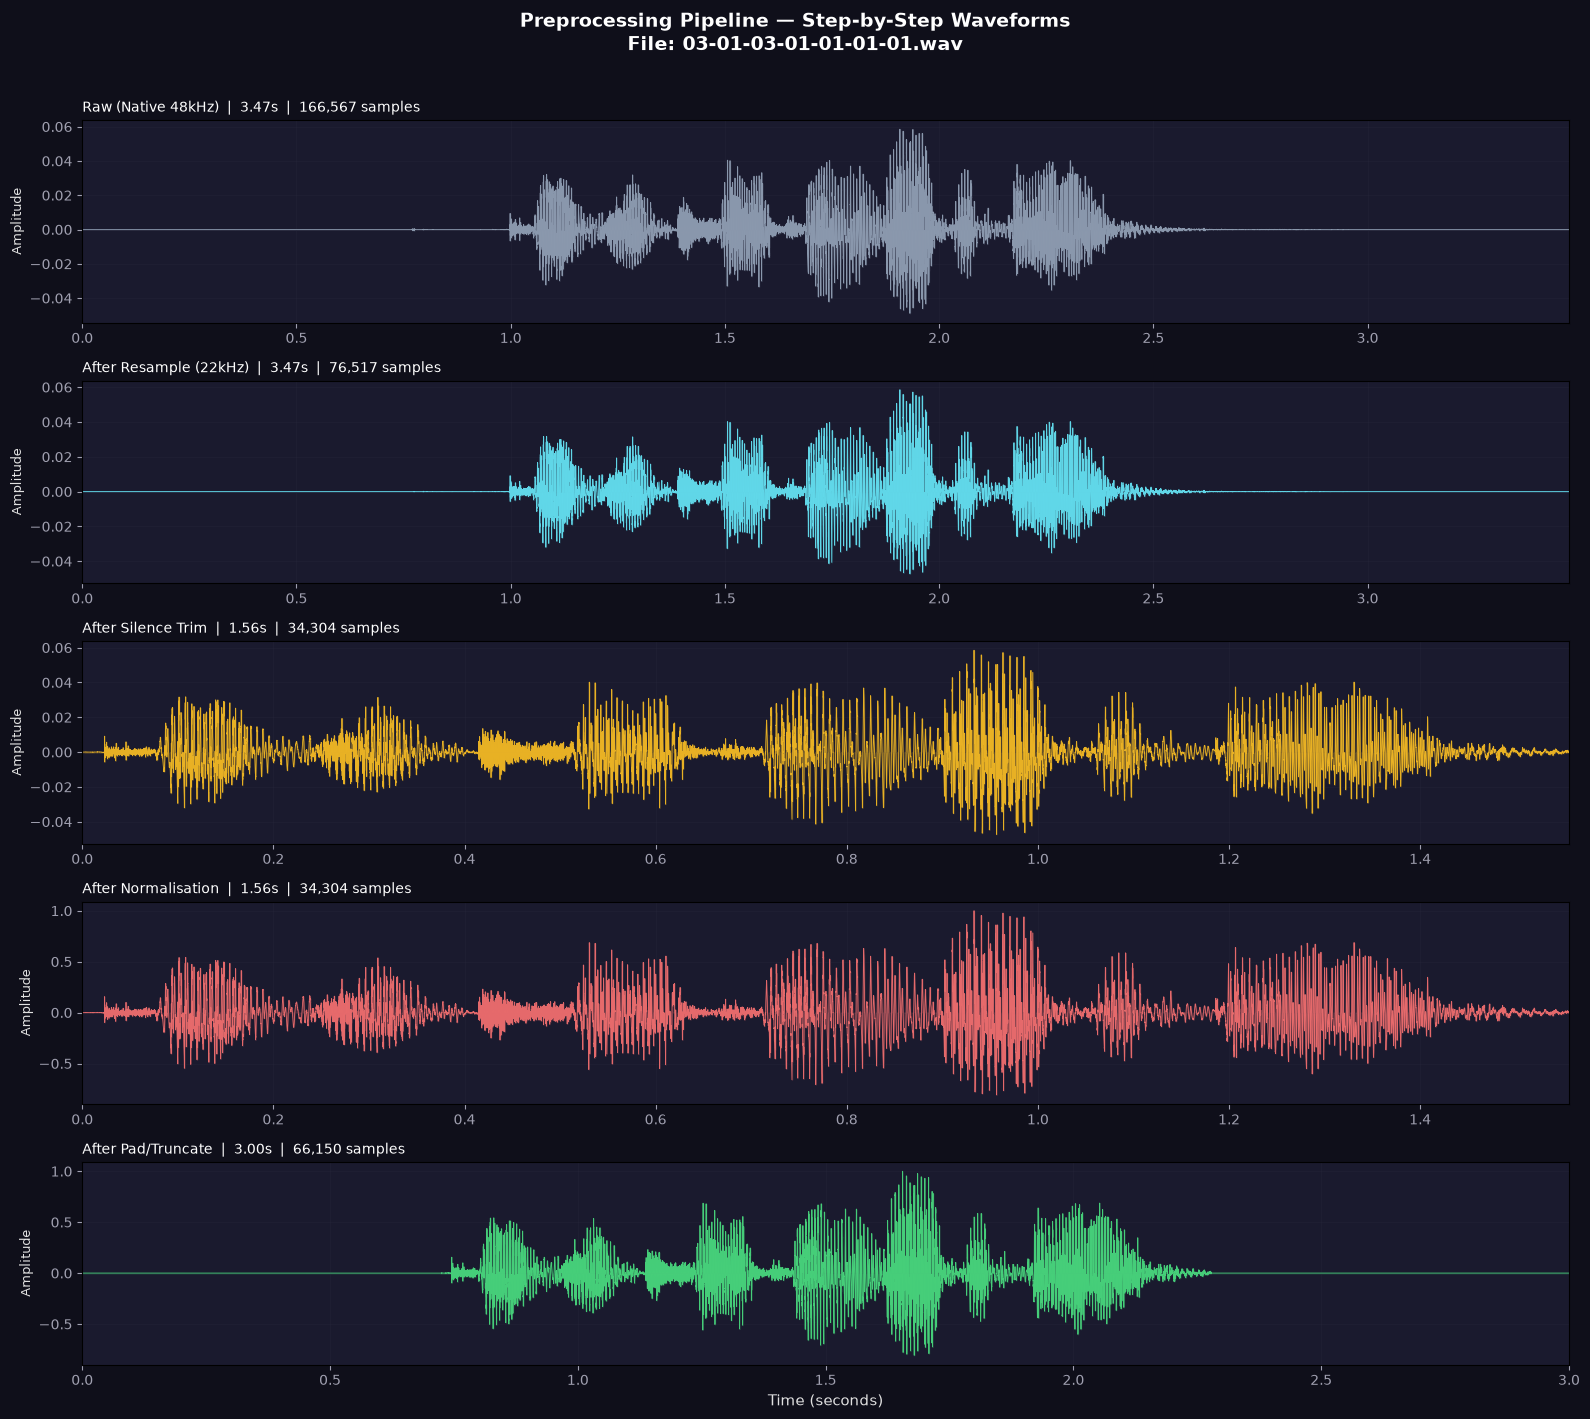

✅ Plot saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\preprocessing_pipeline.png


In [10]:
stages = [
    (y_native,     sr_native,  'Raw (Native 48kHz)',     '#94a3b8'),
    (y_resampled,  TARGET_SR,  'After Resample (22kHz)', '#67e8f9'),
    (y_trimmed,    TARGET_SR,  'After Silence Trim',     '#fbbf24'),
    (y_normalised, TARGET_SR,  'After Normalisation',    '#f87171'),
    (y_fixed,      TARGET_SR,  'After Pad/Truncate',     '#4ade80'),
]

fig, axes = plt.subplots(len(stages), 1, figsize=(16, 14))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Preprocessing Pipeline — Step-by-Step Waveforms\n'
             f'File: {os.path.basename(demo_path)}',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for ax, (signal, sr, title, color) in zip(axes, stages):
    ax.set_facecolor('#1a1a2e')
    t = np.linspace(0, len(signal) / sr, len(signal))
    ax.plot(t, signal, color=color, linewidth=0.6, alpha=0.9)
    ax.fill_between(t, signal, alpha=0.15, color=color)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.set_title(f'{title}  |  {len(signal)/sr:.2f}s  |  {len(signal):,} samples',
                 fontsize=10, color='white', loc='left')
    ax.grid(alpha=0.25)
    ax.set_xlim([0, max(len(signal)/sr, 0.01)])

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'waveforms', 'preprocessing_pipeline.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'✅ Plot saved → {save_path}')

## 4.5 — Before vs After Spectrogram Comparison

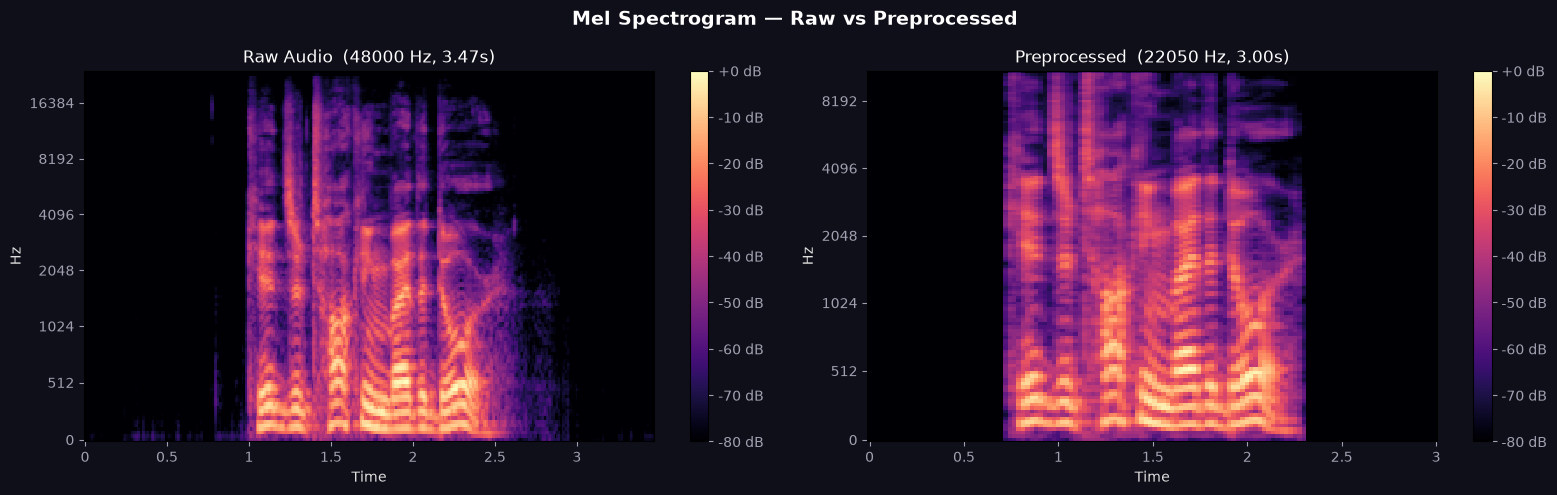

✅ Plot saved → C:\Speech Emotion Recognition\notebooks\..\reports\spectrograms\raw_vs_preprocessed.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Mel Spectrogram — Raw vs Preprocessed', fontsize=14,
             fontweight='bold', color='white')

# Raw spectrogram
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
S_raw = librosa.feature.melspectrogram(y=y_native.astype(np.float32), sr=sr_native, n_mels=128)
S_raw_db = librosa.power_to_db(S_raw, ref=np.max)
img1 = librosa.display.specshow(S_raw_db, sr=sr_native, x_axis='time',
                                 y_axis='mel', ax=ax1, cmap='magma')
ax1.set_title(f'Raw Audio  ({sr_native} Hz, {len(y_native)/sr_native:.2f}s)',
              color='white', fontsize=12)
fig.colorbar(img1, ax=ax1, format='%+2.0f dB')

# Preprocessed spectrogram
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
S_pre = librosa.feature.melspectrogram(y=y_fixed.astype(np.float32), sr=TARGET_SR, n_mels=128)
S_pre_db = librosa.power_to_db(S_pre, ref=np.max)
img2 = librosa.display.specshow(S_pre_db, sr=TARGET_SR, x_axis='time',
                                 y_axis='mel', ax=ax2, cmap='magma')
ax2.set_title(f'Preprocessed  ({TARGET_SR} Hz, {len(y_fixed)/TARGET_SR:.2f}s)',
              color='white', fontsize=12)
fig.colorbar(img2, ax=ax2, format='%+2.0f dB')

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'spectrograms', 'raw_vs_preprocessed.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'✅ Plot saved → {save_path}')

## 4.6 — Compare Waveforms Across 3 Emotions (Post-Processing)

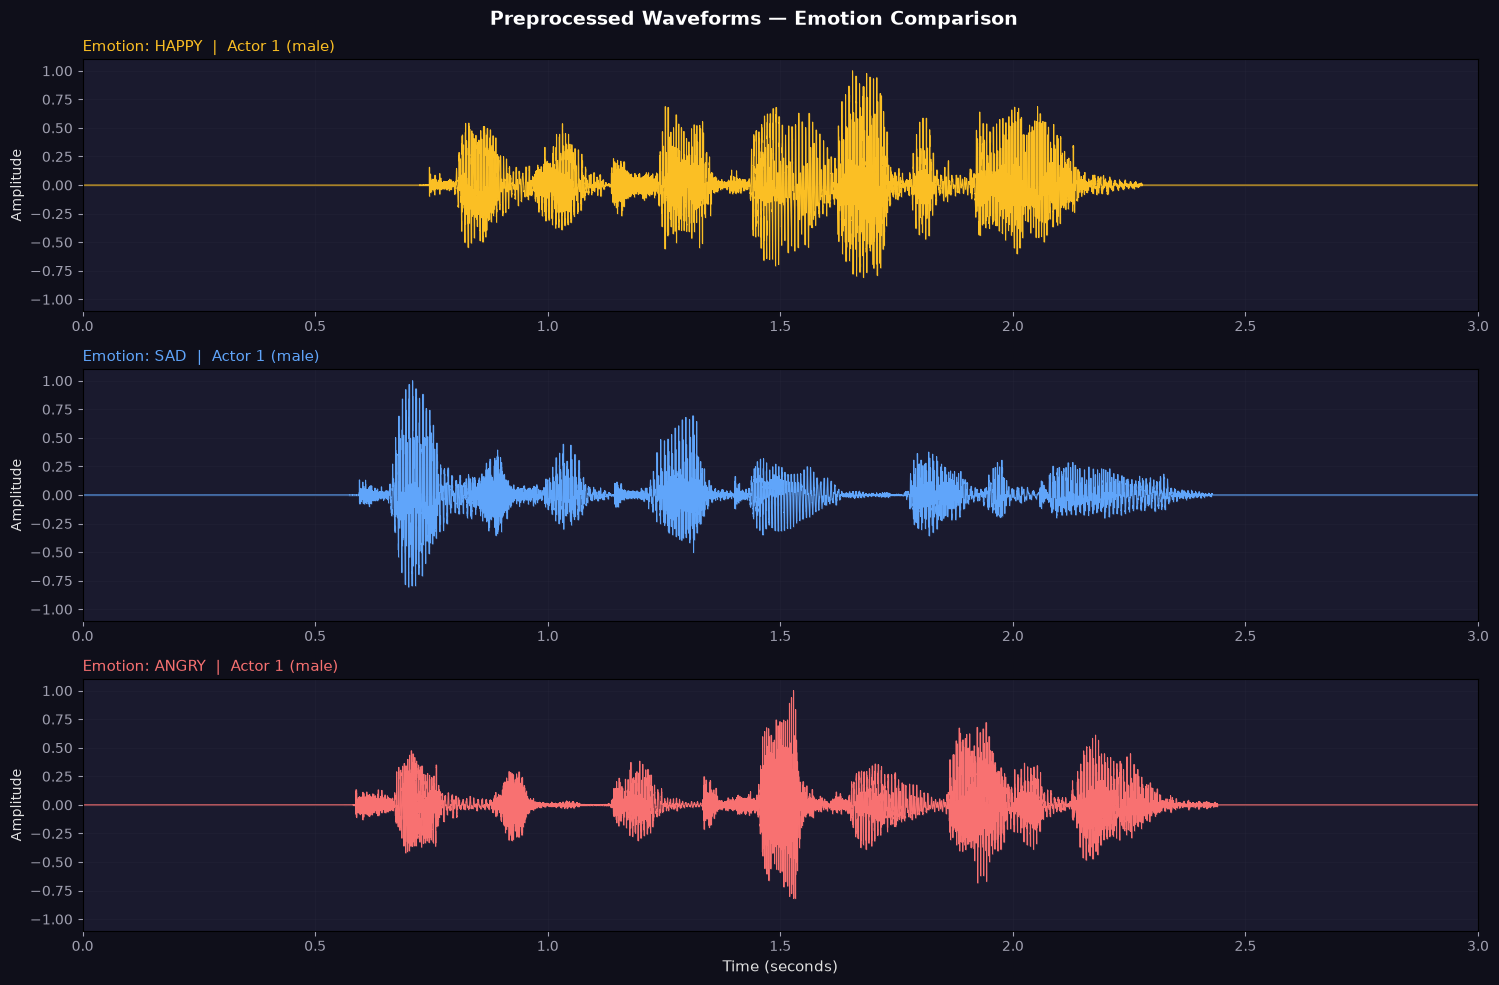

✅ Plot saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\emotion_waveforms_comparison.png


In [12]:
def preprocess_audio(filepath, target_sr=TARGET_SR,
                     target_samples=TARGET_SAMPLES, top_db=TOP_DB):
    """
    Full preprocessing pipeline for a single audio file.
    Returns the cleaned, fixed-length numpy array.
    """
    y, sr  = librosa.load(filepath, sr=None)
    if y.ndim > 1:
        y = librosa.to_mono(y)
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    y, _   = librosa.effects.trim(y, top_db=top_db)
    mx = np.max(np.abs(y))
    if mx > 0:
        y = y / mx
    # Pad or truncate
    if len(y) < target_samples:
        pad = target_samples - len(y)
        y   = np.pad(y, (pad//2, pad - pad//2), mode='constant')
    else:
        y = y[:target_samples]
    return y


# Demo: compare 3 emotions after preprocessing
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Preprocessed Waveforms — Emotion Comparison',
             fontsize=14, fontweight='bold', color='white')

compare_emotions = ['happy', 'sad', 'angry']
t = np.linspace(0, TARGET_DURATION, TARGET_SAMPLES)

for ax, emotion in zip(axes, compare_emotions):
    row  = df[df['emotion'] == emotion].iloc[0]
    sig  = preprocess_audio(row['filepath'])
    clr  = EMOTION_COLORS[emotion]

    ax.set_facecolor('#1a1a2e')
    ax.plot(t, sig, color=clr, linewidth=0.7)
    ax.fill_between(t, sig, alpha=0.18, color=clr)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(f'Emotion: {emotion.upper()}  |  '
                 f'Actor {row["actor"]} ({row["gender"]})',
                 color=clr, fontsize=11, loc='left')
    ax.set_xlim([0, TARGET_DURATION])
    ax.set_ylim([-1.1, 1.1])
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'waveforms', 'emotion_waveforms_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'✅ Plot saved → {save_path}')

## 4.7 — Batch Preprocess All 1,440 Audio Files

In [13]:
from tqdm.auto import tqdm

print(f'🚀 Starting batch preprocessing of {len(df)} audio files...')
print(f'   Target SR       : {TARGET_SR} Hz')
print(f'   Target Duration : {TARGET_DURATION} sec')
print(f'   Target Samples  : {TARGET_SAMPLES:,}')
print()

signals    = []
failed     = []
final_durs = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='Preprocessing'):
    try:
        sig = preprocess_audio(row['filepath'])
        signals.append(sig)
        final_durs.append(len(sig) / TARGET_SR)
    except Exception as e:
        print(f'  ❌ Failed: {row["filename"]}  →  {e}')
        signals.append(np.zeros(TARGET_SAMPLES))  # zero-fill on error
        failed.append(row['filename'])
        final_durs.append(0.0)

X_audio = np.array(signals, dtype=np.float32)  # shape: (1440, 66150)

print(f'\n✅ Preprocessing complete!')
print(f'   Output array shape : {X_audio.shape}')
print(f'   Dtype              : {X_audio.dtype}')
print(f'   Memory size        : {X_audio.nbytes / 1024**2:.1f} MB')
print(f'   Failed files       : {len(failed)}')

🚀 Starting batch preprocessing of 1440 audio files...
   Target SR       : 22050 Hz
   Target Duration : 3.0 sec
   Target Samples  : 66,150



Preprocessing:   0%|          | 0/1440 [00:00<?, ?it/s]


✅ Preprocessing complete!
   Output array shape : (1440, 66150)
   Dtype              : float32
   Memory size        : 363.4 MB
   Failed files       : 0


## 4.8 — Verify & Inspect Preprocessed Array

In [14]:
print('🔍 Post-Processing Quality Check')
print('─' * 50)
print(f'  Total samples           : {X_audio.shape[0]}')
print(f'  Samples per clip        : {X_audio.shape[1]:,}')
print(f'  Duration per clip       : {X_audio.shape[1]/TARGET_SR:.3f} sec')
print(f'  Global amplitude min    : {X_audio.min():.4f}')
print(f'  Global amplitude max    : {X_audio.max():.4f}')
print(f'  Any NaN values?         : {np.isnan(X_audio).any()}')
print(f'  Any Inf values?         : {np.isinf(X_audio).any()}')
print(f'  Clips with all zeros    : {np.sum(np.all(X_audio == 0, axis=1))}')
print('─' * 50)
print(f'✅ All clips have exactly {TARGET_SAMPLES:,} samples: '
      f'{np.all(np.array([len(s) for s in signals]) == TARGET_SAMPLES)}')

🔍 Post-Processing Quality Check
──────────────────────────────────────────────────
  Total samples           : 1440
  Samples per clip        : 66,150
  Duration per clip       : 3.000 sec
  Global amplitude min    : -1.0000
  Global amplitude max    : 1.0000


  Any NaN values?         : False


  Any Inf values?         : False


  Clips with all zeros    : 0
──────────────────────────────────────────────────
✅ All clips have exactly 66,150 samples: True


## 4.9 — Visualise Amplitude Distribution After Normalisation

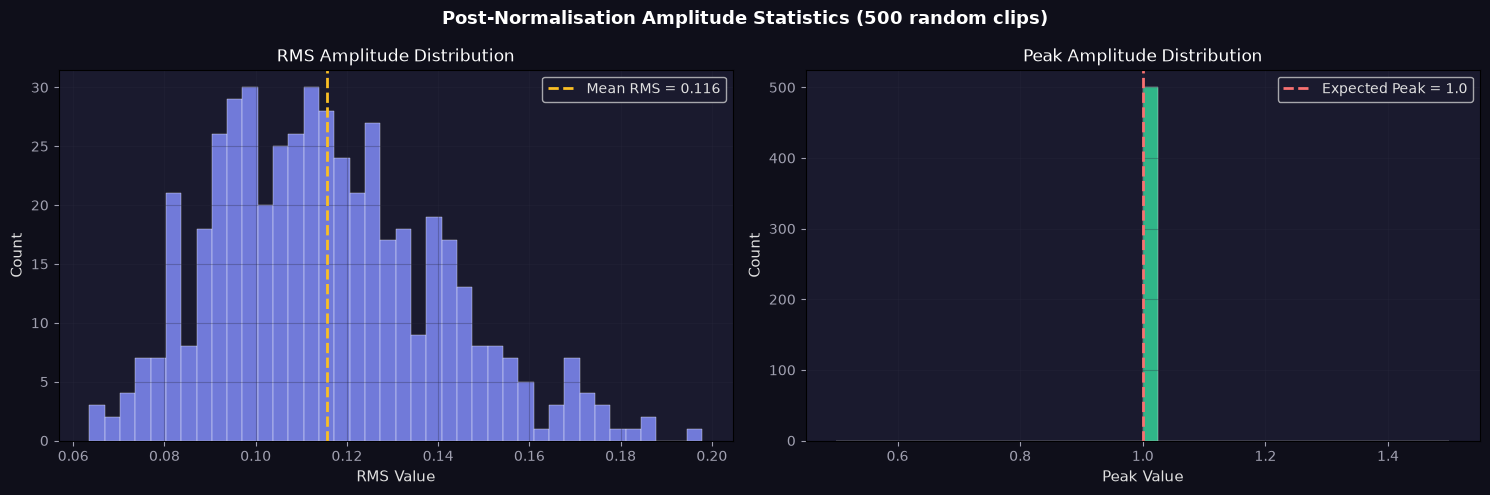

✅ Plot saved → C:\Speech Emotion Recognition\notebooks\..\reports\waveforms\amplitude_distribution.png


In [15]:
# Sample 500 random clips for distribution plot
sample_idx  = np.random.choice(len(X_audio), size=min(500, len(X_audio)), replace=False)
rms_vals    = [np.sqrt(np.mean(X_audio[i]**2)) for i in sample_idx]
peak_vals   = [np.max(np.abs(X_audio[i]))      for i in sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f1a')
fig.suptitle('Post-Normalisation Amplitude Statistics (500 random clips)',
             fontsize=13, color='white', fontweight='bold')

ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
ax1.hist(rms_vals, bins=40, color='#818cf8', edgecolor='white', linewidth=0.3, alpha=0.85)
ax1.axvline(np.mean(rms_vals), color='#fbbf24', linestyle='--', linewidth=2,
            label=f'Mean RMS = {np.mean(rms_vals):.3f}')
ax1.set_title('RMS Amplitude Distribution', color='white', fontsize=12)
ax1.set_xlabel('RMS Value', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.hist(peak_vals, bins=40, color='#34d399', edgecolor='white', linewidth=0.3, alpha=0.85)
ax2.axvline(1.0, color='#f87171', linestyle='--', linewidth=2, label='Expected Peak = 1.0')
ax2.set_title('Peak Amplitude Distribution', color='white', fontsize=12)
ax2.set_xlabel('Peak Value', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'waveforms', 'amplitude_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f'✅ Plot saved → {save_path}')

## 4.10 — Save Preprocessed Audio Arrays to Disk

In [16]:
# Build labels array
emotion_labels = df['emotion'].values
emotion_list   = list(EMOTION_MAP.values())          # 8 classes
y_encoded      = np.array([emotion_list.index(e) for e in emotion_labels], dtype=np.int32)

# Save processed arrays
np.save(os.path.join(DATA_PROC, 'X_audio.npy'), X_audio)
np.save(os.path.join(DATA_PROC, 'y_labels.npy'), y_encoded)

# Save updated metadata with label encoding
df['label_encoded'] = y_encoded
df.to_csv(os.path.join(FEATURES_DIR, 'dataset_metadata.csv'), index=False)

# Save label class list
import json
label_info = {'emotion_classes': emotion_list, 'num_classes': len(emotion_list),
              'target_sr': TARGET_SR, 'target_duration': TARGET_DURATION,
              'target_samples': TARGET_SAMPLES}
with open(os.path.join(DATA_PROC, 'preprocessing_config.json'), 'w') as f:
    json.dump(label_info, f, indent=2)

print('✅ Preprocessed data saved!')
print(f'   X_audio.npy  →  shape {X_audio.shape}  ({X_audio.nbytes/1024**2:.1f} MB)')
print(f'   y_labels.npy →  shape {y_encoded.shape}')
print(f'   preprocessing_config.json saved')
print()
print('📋 Label Encoding:')
for idx, em in enumerate(emotion_list):
    count = np.sum(y_encoded == idx)
    print(f'   {idx}  →  {em:<10}  ({count} samples)')

✅ Preprocessed data saved!
   X_audio.npy  →  shape (1440, 66150)  (363.4 MB)
   y_labels.npy →  shape (1440,)
   preprocessing_config.json saved

📋 Label Encoding:
   0  →  neutral     (96 samples)
   1  →  calm        (192 samples)
   2  →  happy       (192 samples)
   3  →  sad         (192 samples)
   4  →  angry       (192 samples)
   5  →  fearful     (192 samples)
   6  →  disgust     (192 samples)
   7  →  surprised   (192 samples)


## 4.11 — Final Verification Dashboard

In [17]:
# Reload from disk to confirm save/load integrity
X_verify = np.load(os.path.join(DATA_PROC, 'X_audio.npy'))
y_verify = np.load(os.path.join(DATA_PROC, 'y_labels.npy'))

print('🔁 Reload & Integrity Verification')
print('─' * 55)
print(f'  X_audio loaded shape  : {X_verify.shape}')
print(f'  y_labels loaded shape : {y_verify.shape}')
print(f'  Max value in X        : {X_verify.max():.4f}  (should be ≤ 1.0)')
print(f'  Min value in X        : {X_verify.min():.4f}  (should be ≥ -1.0)')
print(f'  NaN in X              : {np.isnan(X_verify).sum()}')
print(f'  Unique labels in y    : {np.unique(y_verify)}')
print(f'  Label counts          :')
for i, em in enumerate(emotion_list):
    print(f'    {i} {em:<10} : {np.sum(y_verify==i)}')
print('─' * 55)
print('✅ Data integrity confirmed — preprocessing complete!')

🔁 Reload & Integrity Verification
───────────────────────────────────────────────────────
  X_audio loaded shape  : (1440, 66150)
  y_labels loaded shape : (1440,)
  Max value in X        : 1.0000  (should be ≤ 1.0)
  Min value in X        : -1.0000  (should be ≥ -1.0)
  NaN in X              : 0
  Unique labels in y    : [0 1 2 3 4 5 6 7]
  Label counts          :
    0 neutral    : 96
    1 calm       : 192
    2 happy      : 192
    3 sad        : 192
    4 angry      : 192
    5 fearful    : 192
    6 disgust    : 192
    7 surprised  : 192
───────────────────────────────────────────────────────
✅ Data integrity confirmed — preprocessing complete!


## 4.12 — Module 4 Summary

| Step | Operation | Result |
|---|---|---|
| 1 | **Load** | Loaded with `librosa.load()` at native 48kHz |
| 2 | **Mono** | RAVDESS is already mono — confirmed |
| 3 | **Resample** | 48kHz → **22,050 Hz** (standard ML rate) |
| 4 | **Trim Silence** | Removed leading/trailing silence (top_db=30) |
| 5 | **Normalise** | Peak normalised to [-1.0, +1.0] |
| 6 | **Fixed Length** | Centre-padded or truncated to **3.0 seconds** = 66,150 samples |
| 7 | **Save** | `data/processed/X_audio.npy`  &  `y_labels.npy` |

### Output Files
| File | Shape | Description |
|---|---|---|
| `data/processed/X_audio.npy` | (1440, 66150) | Preprocessed audio signals |
| `data/processed/y_labels.npy` | (1440,) | Integer emotion labels 0–7 |
| `data/processed/preprocessing_config.json` | — | Config used for preprocessing |
| `features/dataset_metadata.csv` | (1440, N) | Full metadata with label encoding |

✅ **Module 4 Complete — Ready for Module 5: Speech Signal Exploratory Analysis**